# Bayesian optimization

This section provides implementation for concepts related to Bayesian optimization (BO). Primarily, BO is aimed at solving an optimization problem that involves expensive-to-evaluate blackbox function $f: \Omega \rightarrow \mathcal{R}$. In other words, the function form of $f$ is not available and one can only evaluate $f$ at a limited number of input points to determine the optimum value. Mathematically, the optimization problem is written as

$$
    \max_{\mathbf{x} \in \Omega} f(x),
$$

where $\mathbf{x}$ is the design variable vector and $\Omega \subset \mathcal{R}^n$ is the design space.

BO consists of adaptively selecting test points while balancing a trade-off between exploration (regions of high uncertainty) and exploitation (regions of observed good performance). Specifically, BO performs an auxillary optimization to perform this trade-off. The auxillary optimization consists of maximizing an acquisition function which balances this trade-off. Various acquisition functions have been proposed in literature but this section will focus on following functions:

1. Exploitation
2. Lower Confidence Bound
3. Probability of Improvement
4. Expected Improvement

To solve the auxiliary optimization problem, we will be using a global optimization algorithm called [differential evolution](https://en.wikipedia.org/wiki/Differential_evolution). One can also use gradient-based optimization to solve this auxiliary optimization problem. However, many of these acquisition functions are non-convex and may have multiple local minima. Hence, in this section, we are using global optimization method for solving auxiliary optimization problem. We are going to use [pymoo](https://pymoo.org/) package which provides a convenient interface for performing global optimization using various methods, including differential evolution.

> **_NOTE:_** Before proceeding to next section, install pymoo in the environment you created for this class using `pip install pymoo`.

To demonstrate the working of BO and above acquistion functions, the **Modified Branin function** is used. This function is written as

$$
    \begin{gathered}
        f(x_1, x_2) = \Bigg ( x_2 - \frac{5.1}{4\pi^2} x_1^2 + \frac{5}{\pi}x_1 - 6 \Bigg)^2 + 10 \Bigg( 1-\frac{1}{8\pi} \Bigg)\cos x_1 + 10 + 5x_1 \\
        -5 \leq x_1 \leq 10 \text{ and } 0 \leq x_2 \leq 15.
    \end{gathered}
$$

The global minimum of this function is $f(x^*) = -16.644$ at $x^* = (-3.689, 13.630)$. Below block of code plots the true function, global minimum, and local minima.

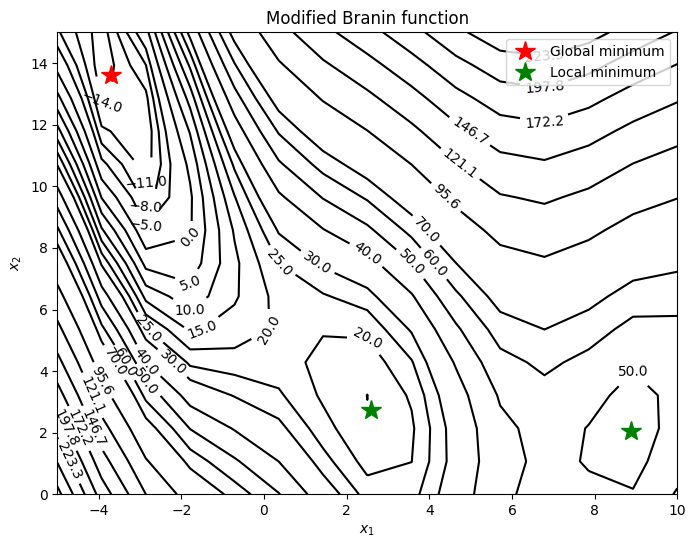

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def modified_branin(x):

    dim = x.ndim

    if dim == 1:
        x = x.reshape(1, -1)

    x1 = x[:,0]
    x2 = x[:,1]

    b = 5.1 / (4*np.pi**2)
    c = 5 / np.pi
    t = 1 / (8*np.pi)

    y = (x2 - b*x1**2 + c*x1 - 6)**2 + 10*(1-t)*np.cos(x1) + 10 + 5*x1

    if dim == 1:
        y = y.reshape(-1)

    return y

# Bounds
lb = np.array([-5, 0])
ub = np.array([10, 15])

num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(40, 60, 3)))
levels = np.concatenate((levels, np.linspace(70, 300, 10)))

fig, ax = plt.subplots(figsize=(8,6))
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid')
ax.clabel(CS, inline=1)
ax.plot(-3.689, 13.630, 'r*', markersize=15, label="Global minimum")
ax.plot(2.594, 2.741, 'g*', markersize=15, label="Local minimum")
ax.plot(8.877, 2.052,'g*', markersize=15)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Modified Branin function")
_ = ax.legend(loc="upper right")

As can be seen from above plot, the function has multiple local minima and the goal is to find the global minimum using surrogate model and sequential sampling.